In [ ]:
<center><img src="https://image-cdn.hypb.st/https%3A%2F%2Fhypebeast.com%2Fimage%2F2022%2F06%2Ftesla-stock-split-three-way-price-reset-filing-000.jpg?w=960&cbr=1&q=90&fit=max" width="400" height="400"></center>

In [ ]:
<h1 align="center">TESLA stock price prediction (2017-2022)</h1>
<p style="text-align:center;">Historical Data for Tesla Inc. (5 Years)</p>

In [ ]:
## About Dataset
[Tesla](https://www.tesla.com/), Inc. designs, develops, manufactures, leases, and sells electric vehicles, and energy generation and storage systems in the United States, China, and internationally. The company operates in two segments, Automotive, and Energy Generation and Storage. The Automotive segment offers electric vehicles, as well as sells automotive regulatory credits. It provides sedans and sport utility vehicles through direct and used vehicle sales, a network of Tesla Superchargers, and in-app upgrades; and purchase financing and leasing services. This segment is also involved in the provision of non-warranty after-sales vehicle services, sale of used vehicles, retail merchandise, and vehicle insurance, as well as sale of products to third party customers; services for electric vehicles through its company-owned service locations, and Tesla mobile service technicians; and vehicle limited warranties and extended service plans. The Energy Generation and Storage segment engages in the design, manufacture, installation, sale, and leasing of solar energy generation and energy storage products, and related services to residential, commercial, and industrial customers and utilities through its website, stores, and galleries, as well as through a network of channel partners.

In [ ]:
## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
## Import dataset

In [3]:
import pandas as pd

df = pd.read_csv("TSLA.csv")

print(df.head())
print(df.shape)

         Date       Open   High        Low      Close  Adj Close    Volume
0  2010-06-29  19.000000  25.00  17.540001  23.889999  23.889999  18766300
1  2010-06-30  25.790001  30.42  23.299999  23.830000  23.830000  17187100
2  2010-07-01  25.000000  25.92  20.270000  21.959999  21.959999   8218800
3  2010-07-02  23.000000  23.10  18.709999  19.200001  19.200001   5139800
4  2010-07-06  20.000000  20.00  15.830000  16.110001  16.110001   6866900
(2416, 7)


In [ ]:
## Step 2: Data Loading + Data Cleaning + Missing Values Analysis + EDA

In [ ]:
## 2.1 Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [ ]:
## 2.2 Load Dataset

In [5]:
df = pd.read_csv("TSLA.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2416, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [ ]:
## 2.3 Basic Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [ ]:
## 2.4 Check Data Types

In [7]:
df.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [ ]:
## 2.5 Check Missing Values

In [8]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

Date         0.0
Open         0.0
High         0.0
Low          0.0
Close        0.0
Adj Close    0.0
Volume       0.0
dtype: float64

In [ ]:
## 2.6 Remove Duplicate Rows

In [11]:
print("Duplicates:",df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates After Cleaning:",df.duplicated().sum())

Duplicates: 0
Duplicates After Cleaning: 0


In [ ]:
## 2.7 Convert Date Column

In [13]:
df['Date']=pd.to_datetime(df['Date'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[ns]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 132.3 KB


In [ ]:
## 2.8 Set Date as Index

In [20]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [ ]:
## 2.9 Statistical Summary

In [21]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [ ]:
## 2.10 Correlation Heatmap

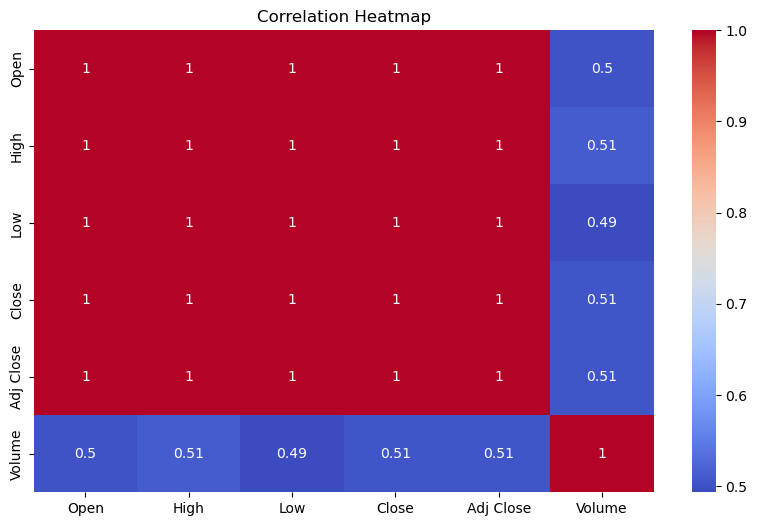

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
### 2.11 Closing Price Trend

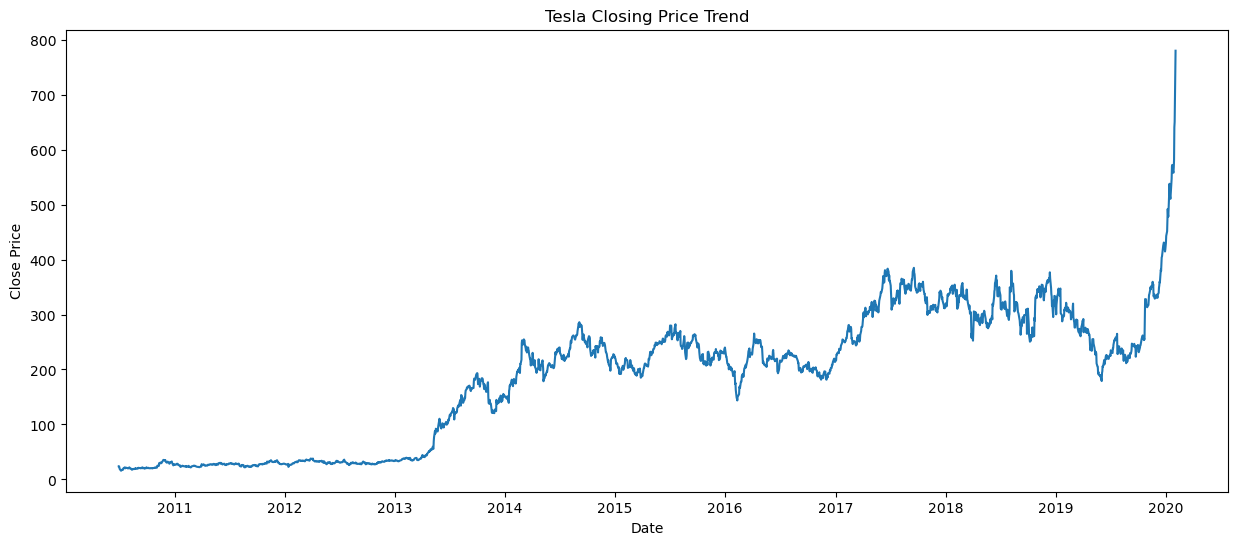

In [25]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'])

plt.title("Tesla Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

## 2.12 Volume Trend

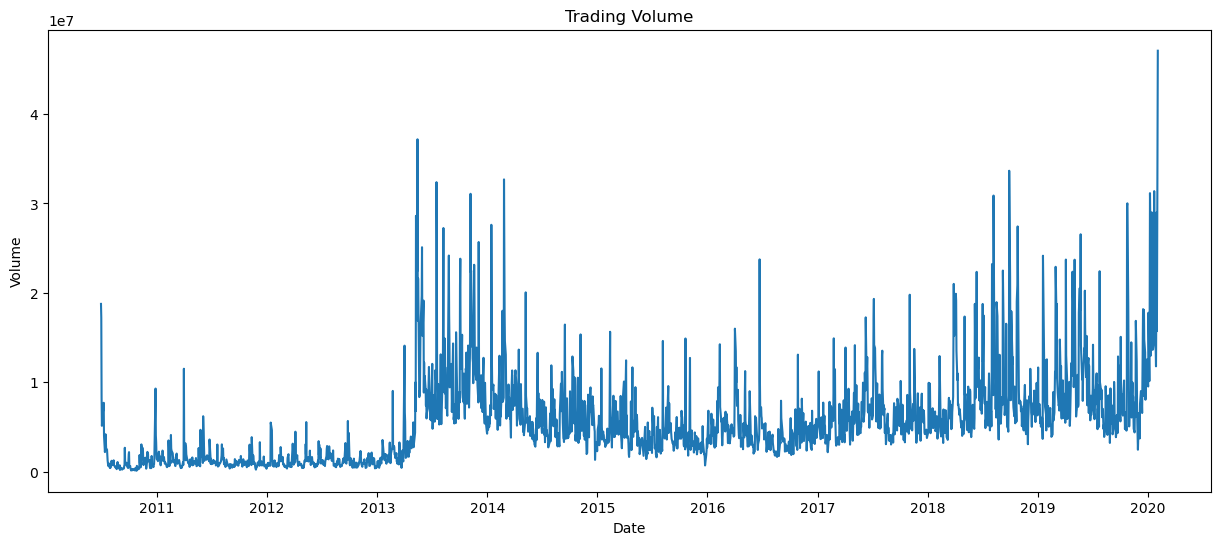

In [26]:
plt.figure(figsize=(15,6))

plt.plot(df['Volume'])

plt.title("Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

## 2.13 Distribution of Close Price

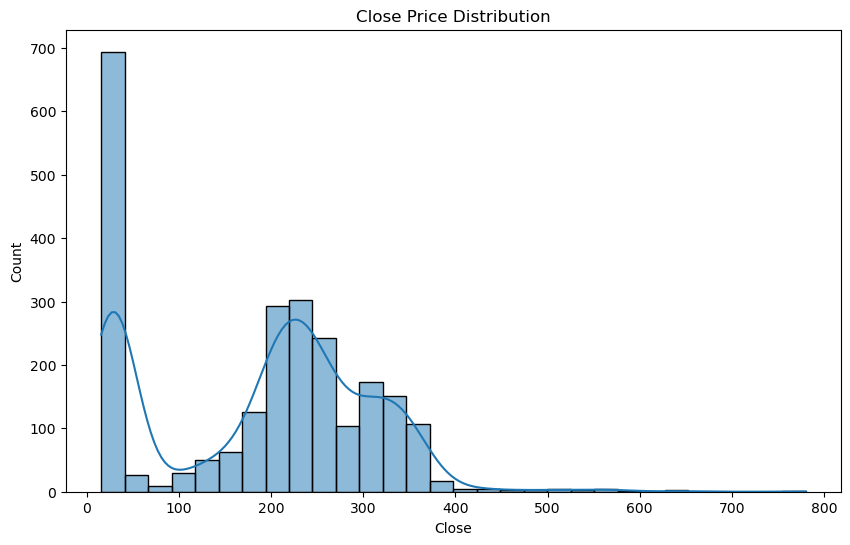

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(df['Close'],bins=30,kde=True)

plt.title("Close Price Distribution")

plt.show()

## 2.14 Boxplot (Outlier Detection)

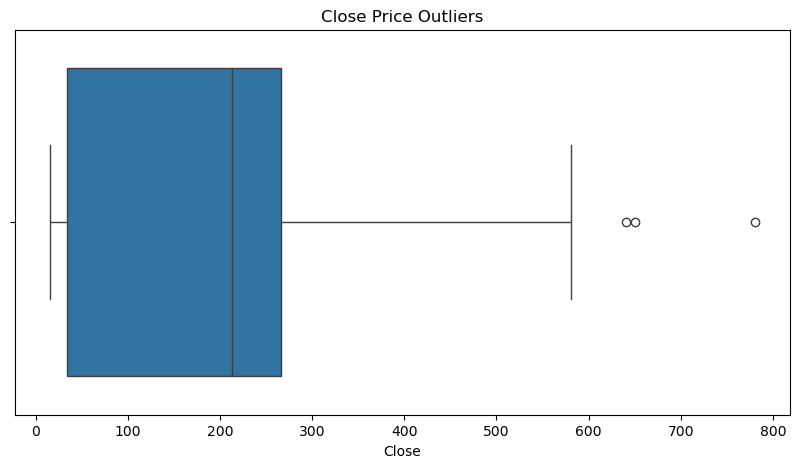

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Close'])

plt.title("Close Price Outliers")

plt.show()

## Step 3.1 Close Price Select

In [29]:
data = df[['Close']]

data.head()

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


## Step 3.2 MinMaxScaler

In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.01058623]
 [0.01050772]
 [0.00806072]
 [0.0044491 ]
 [0.00040565]]


## Step 3.3 Train-Test Split

In [31]:
train_size = int(len(scaled_data)*0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print("Train Size:",len(train_data))
print("Test Size:",len(test_data))

Train Size: 1932
Test Size: 484


## Step 3.4 Sequence Function

In [32]:
def create_sequences(dataset,time_step):
    
    X=[]
    y=[]
    
    for i in range(len(dataset)-time_step):
        
        X.append(dataset[i:(i+time_step),0])
        
        y.append(dataset[i+time_step,0])
        
    return np.array(X),np.array(y)

## Step 3.5 Window Size

In [33]:
time_step = 30

## Step 3.6 Train Sequences

In [34]:
X_train,y_train = create_sequences(
    train_data,
    time_step
)

print(X_train.shape)
print(y_train.shape)

(1902, 30)
(1902,)


## Step 3.7 Test Sequences

In [35]:
X_test,y_test = create_sequences(
    test_data,
    time_step
)

print(X_test.shape)
print(y_test.shape)

(454, 30)
(454,)


## Step 3.8 Reshape for RNN/LSTM

In [36]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train.shape)
print(X_test.shape)

(1902, 30, 1)
(454, 30, 1)


## Step 3.9 Sequence Visualization

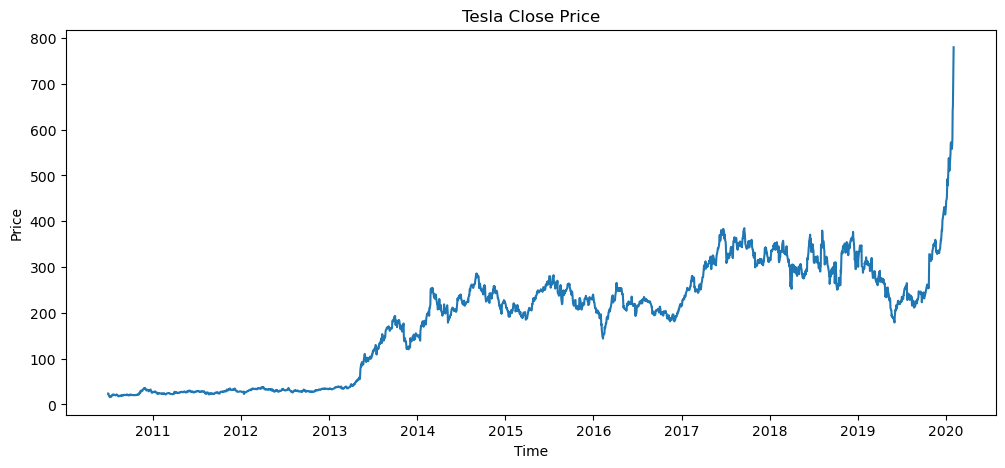

In [37]:
plt.figure(figsize=(12,5))

plt.plot(data['Close'])

plt.title("Tesla Close Price")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()

## Step 4.1 TensorFlow Import

In [38]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

## Step 4.2 Build SimpleRNN Model

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

rnn_model.add(
    Dropout(0.2)
)

rnn_model.add(
    SimpleRNN(
        units=50
    )
)

rnn_model.add(
    Dropout(0.2)
)

rnn_model.add(
    Dense(1)
)

rnn_model.summary()

In [45]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4.3 Compile Model

In [46]:
rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [47]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test,y_test),
    verbose=1
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0379 - val_loss: 0.0024
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0085 - val_loss: 0.0037
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0051 - val_loss: 0.0016
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0033 - val_loss: 0.0013
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0019 - val_loss: 8.7545e-04
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0015 - val_loss: 9.1935e-04
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - val_loss: 9.2840e-04
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 8.0313e-04
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/

## Step 4.4 Early Stopping

In [48]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

## Step 4.5 Train Model

In [50]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test,y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.0812e-04 - val_loss: 5.4555e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1998e-04 - val_loss: 4.7614e-04
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.3523e-04 - val_loss: 4.8082e-04
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.7902e-04 - val_loss: 4.0495e-04
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.1144e-04 - val_loss: 5.3570e-04
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.0508e-04 - val_loss: 4.5994e-04
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7837e-04 - val_loss: 7.3070e-04
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2049e-04 - val_loss: 3.8471e-04
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.8858e-04 - val_loss: 3.9848e-04
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7987e-04 - val_loss: 3.7090e-04
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8015e-0

## Step 4.6 Training Loss Graph

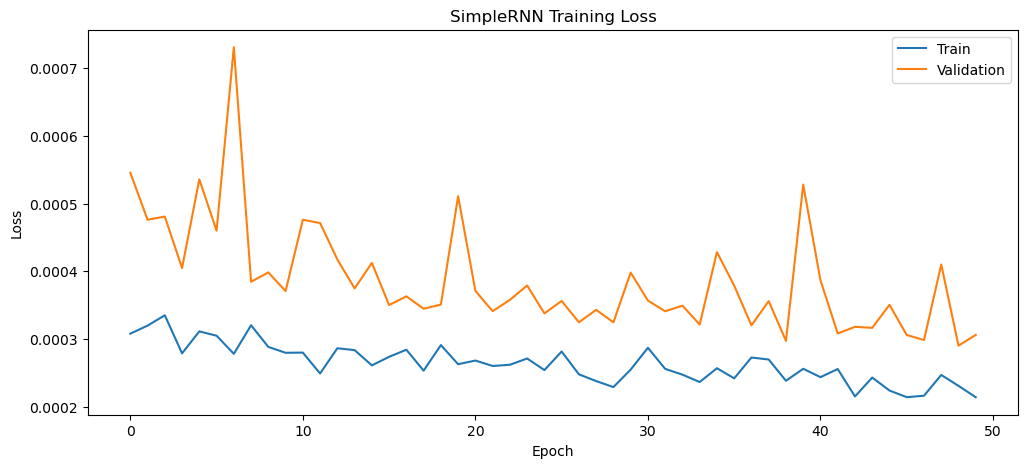

In [51]:
plt.figure(figsize=(12,5))

plt.plot(history_rnn.history['loss'])

plt.plot(history_rnn.history['val_loss'])

plt.title("SimpleRNN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

## Step 4.7 Prediction

In [52]:
rnn_predictions = rnn_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


## Step 4.8 Original Scale Me Convert

In [53]:
rnn_predictions = scaler.inverse_transform(
    rnn_predictions
)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

## Step 4.9 Actual vs Predicted Graph

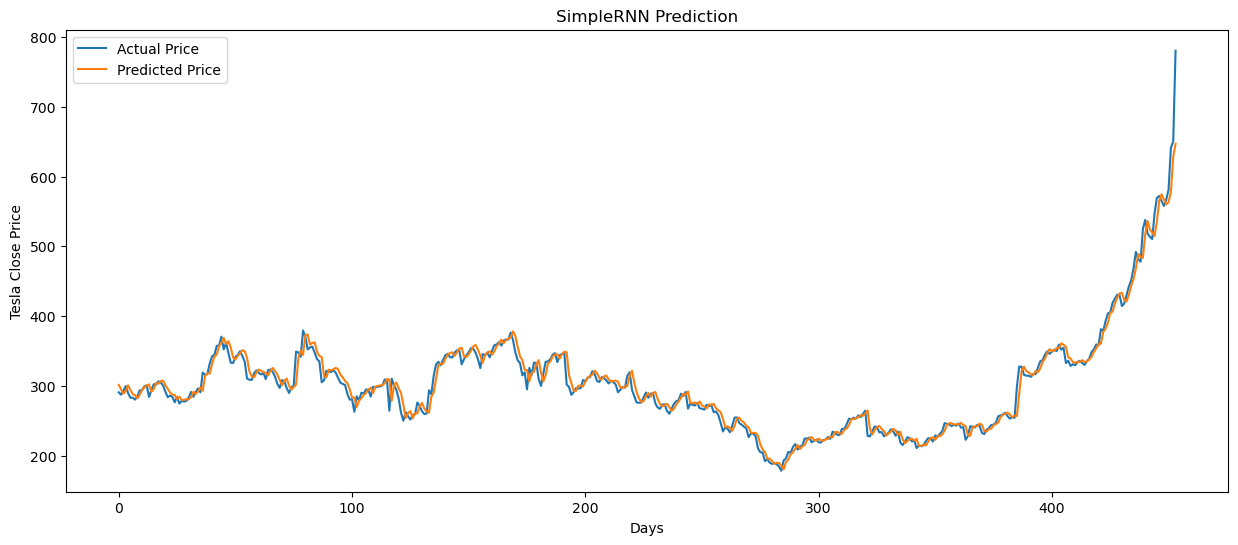

In [54]:
plt.figure(figsize=(15,6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    rnn_predictions,
    label="Predicted Price"
)

plt.title("SimpleRNN Prediction")

plt.xlabel("Days")

plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

## Step 4.10 Evaluation Metrics

In [56]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

mse_rnn = mean_squared_error(
    actual_prices,
    rnn_predictions
)

rmse_rnn = np.sqrt(mse_rnn)

mae_rnn = mean_absolute_error(
    actual_prices,
    rnn_predictions
)

print("SimpleRNN Results")
print()

print("MSE :",mse_rnn)

print("RMSE :",rmse_rnn)

print("MAE :",mae_rnn)

SimpleRNN Results

MSE : 169.62552877354258
RMSE : 13.024036577556997
MAE : 8.078472588378906


## Step 4.11 Save Model

In [57]:
rnn_model.save(
    "simple_rnn_model.h5"
)

## Step 5: LSTM Model

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

## Step 5.2 Build LSTM Model

In [59]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    Dense(1)
)

lstm_model.summary()

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5.3 Compile Model

In [60]:
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

## Step 5.4 Early Stopping

In [61]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

## Step 5.5 Train Model

In [62]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test,y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0041 - val_loss: 0.0021
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.3450e-04 - val_loss: 0.0016
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.2774e-04 - val_loss: 0.0018
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6.4913e-04 - val_loss: 0.0014
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6.1502e-04 - val_loss: 0.0016
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.9205e-04 - val_loss: 0.0012
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.9369e-04 - val_loss: 0.0014
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.4968e-04 - val_loss: 0.0015
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.7864e-04 - val_loss: 0.0015
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.4420e-04 - val_loss: 0.0011
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 5.2449e-04 - val_loss: 0.0011
Epoch 12/50
60/60 ━━━━━

## Step 5.6 Loss Graph

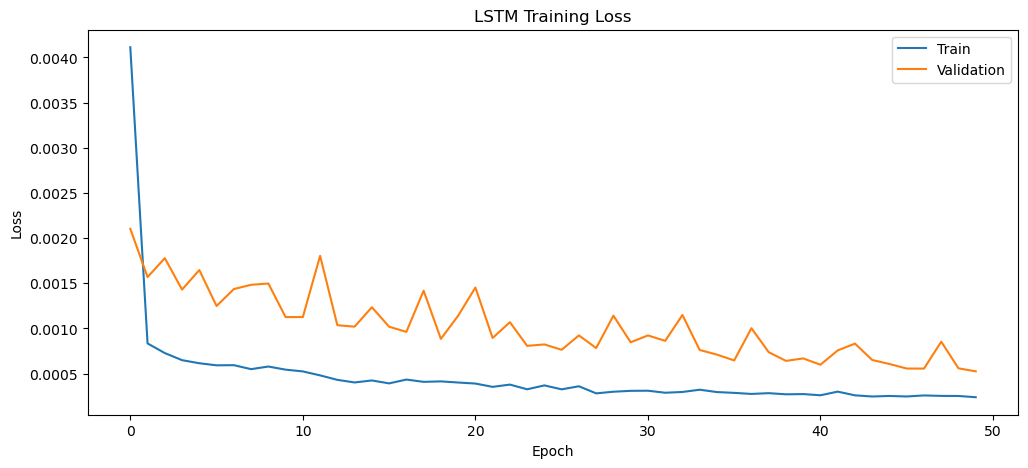

In [63]:
plt.figure(figsize=(12,5))

plt.plot(history_lstm.history['loss'])

plt.plot(history_lstm.history['val_loss'])

plt.title("LSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

## Step 5.7 Prediction

In [64]:
lstm_predictions = lstm_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


## Step 5.8 Inverse Transform

In [66]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

## Step 5.9 Actual vs Predicted

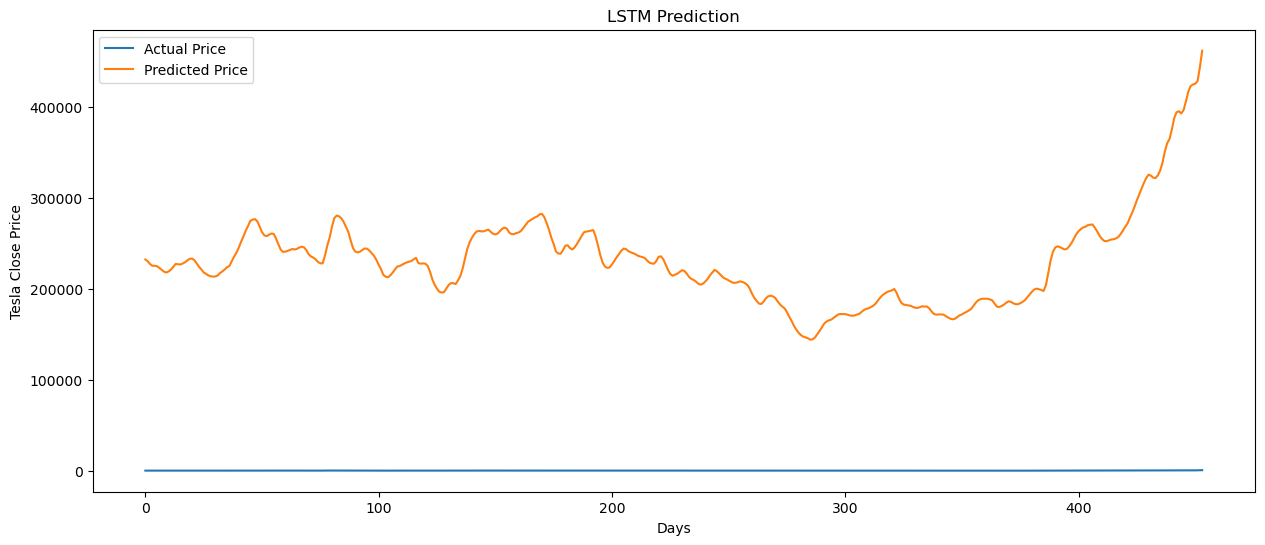

In [67]:
plt.figure(figsize=(15,6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    lstm_predictions,
    label="Predicted Price"
)

plt.title("LSTM Prediction")

plt.xlabel("Days")

plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

## Step 5.10 Evaluation Metrics

In [68]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

mse_lstm = mean_squared_error(
    actual_prices,
    lstm_predictions
)

rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(
    actual_prices,
    lstm_predictions
)

print("LSTM Results")
print()

print("MSE :",mse_lstm)
print("RMSE :",rmse_lstm)
print("MAE :",mae_lstm)

LSTM Results

MSE : 55592420968.949715
RMSE : 235780.45077773032
MAE : 230387.13701253966


## Step 5.11 Save Model

In [71]:
lstm_model.save(
    "lstm_model.keras"
)

## Step 5.12 Compare RNN vs LSTM

In [72]:
comparison = pd.DataFrame({
    "Model":["SimpleRNN","LSTM"],
    "MSE":[mse_rnn,mse_lstm],
    "RMSE":[rmse_rnn,rmse_lstm],
    "MAE":[mae_rnn,mae_lstm]
})

comparison

,Model,MSE,RMSE,MAE
0,SimpleRNN,1.696255e+02,13.024037,8.078473
1,LSTM,5.559242e+10,235780.450778,230387.137013


## Step-6 FUTURE PREDICTION
### 1 DAY, 5 DAYS, 10 DAYS

Next 1 Day Prediction:
660.9505

Next 5 Days Prediction:
[[660.9505 ]
 [680.4142 ]
 [684.9571 ]
 [681.1978 ]
 [672.79706]]

Next 10 Days Prediction:
[[660.9505 ]
 [680.4142 ]
 [684.9571 ]
 [681.1978 ]
 [672.79706]
 [661.86835]
 [649.73267]
 [637.2713 ]
 [625.08826]
 [613.5893 ]]


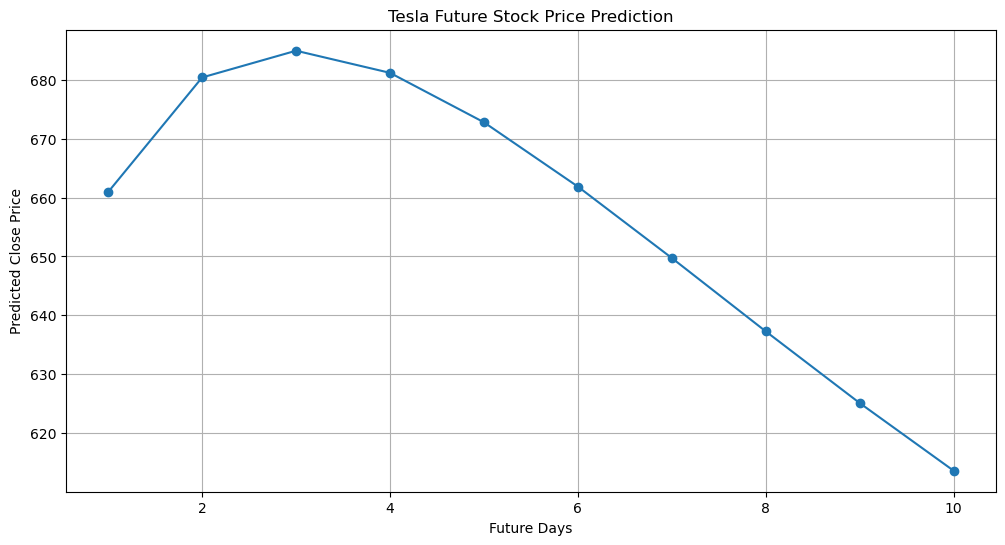

In [73]:
last_30_days = scaled_data[-30:]
future_input = last_30_days.reshape(1,30,1)

future_predictions = []

for i in range(10):

    pred = lstm_model.predict(
        future_input,
        verbose=0
    )

    future_predictions.append(
        pred[0][0]
    )

    future_input = np.append(
        future_input[:,1:,:],
        [[[pred[0][0]]]],
        axis=1
    )

future_predictions = np.array(
    future_predictions
).reshape(-1,1)

future_predictions = scaler.inverse_transform(
    future_predictions
)

print("Next 1 Day Prediction:")
print(future_predictions[0][0])

print("\nNext 5 Days Prediction:")
print(future_predictions[:5])

print("\nNext 10 Days Prediction:")
print(future_predictions)

# Graph

plt.figure(figsize=(12,6))

plt.plot(
    range(1,11),
    future_predictions,
    marker='o'
)

plt.title("Tesla Future Stock Price Prediction")

plt.xlabel("Future Days")

plt.ylabel("Predicted Close Price")

plt.grid(True)

plt.show()

## Step 7: Hyperparameter Tuning

In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

configs = [
    {"units":50,"dropout":0.2},
    {"units":100,"dropout":0.2},
    {"units":100,"dropout":0.3}
]

results = []

for config in configs:

    model = Sequential()

    model.add(
        LSTM(
            config["units"],
            input_shape=(X_train.shape[1],1)
        )
    )

    model.add(
        Dropout(config["dropout"])
    )

    model.add(
        Dense(1)
    )

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_test,y_test),
        verbose=0
    )

    val_loss = min(
        history.history["val_loss"]
    )

    results.append([
        config["units"],
        config["dropout"],
        val_loss
    ])

tuning_results = pd.DataFrame(
    results,
    columns=[
        "Units",
        "Dropout",
        "Validation Loss"
    ]
)

print(tuning_results)

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Units  Dropout  Validation Loss
0     50      0.2         0.000992
1    100      0.2         0.000698
2    100      0.3         0.000875


## TESLA STOCK PRICE PREDICTION MODEL

In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# CSV Load
df = pd.read_csv("TSLA.csv")

# Date column remove (agar ho)
if "Date" in df.columns:
    df = df.drop("Date", axis=1)

print(df.head())

# Features & Target
X = df.drop("Close", axis=1)
y = df["Close"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Save Model
with open("tesla_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model Saved Successfully as tesla_model.pkl")

        Open   High        Low      Close  Adj Close    Volume
0  19.000000  25.00  17.540001  23.889999  23.889999  18766300
1  25.790001  30.42  23.299999  23.830000  23.830000  17187100
2  25.000000  25.92  20.270000  21.959999  21.959999   8218800
3  23.000000  23.10  18.709999  19.200001  19.200001   5139800
4  20.000000  20.00  15.830000  16.110001  16.110001   6866900
R2 Score: 1.0
RMSE: 1.6623255670878598e-13
Model Saved Successfully as tesla_model.pkl
